Dengue columns: ['Age', 'Sex', 'Haemoglobin', 'WBC', 'Differential Count', 'RBC PANEL', 'platelets', 'PDW', 'Final Output']
Malaria columns: ['Sex', 'Age', 'Hemoglobin(Hb%)', 'WBC', 'Neutrophils', 'Lymphocytes', 'Total Cir.Eosinophils', 'HTC/PCV(%)', 'MCH(pg)', 'MCHC(g/dl)', 'RDW-CV(%)', 'platelets', 'Result']
Lab columns loaded successfully.
Unified dataset created with realistic symptoms for ALL fever types!


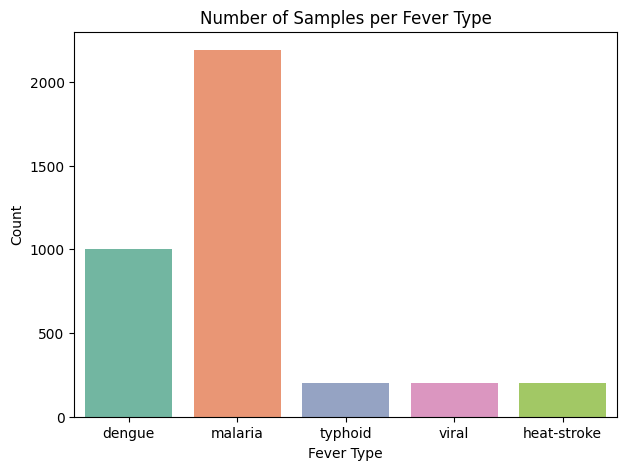

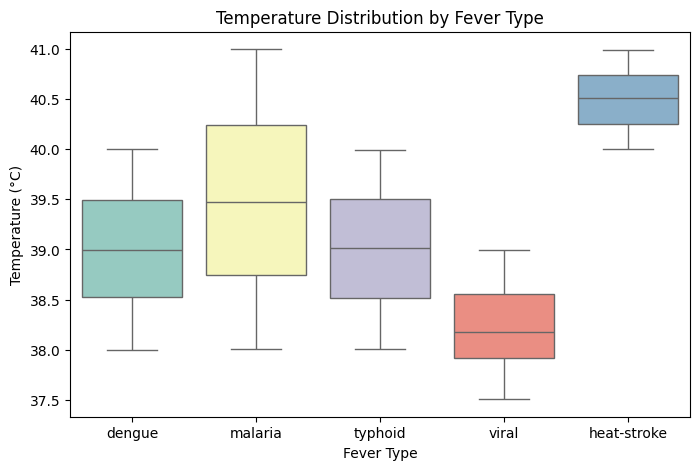

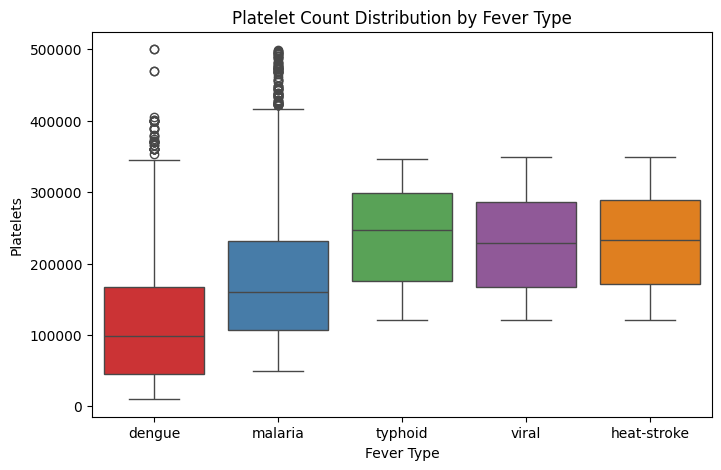

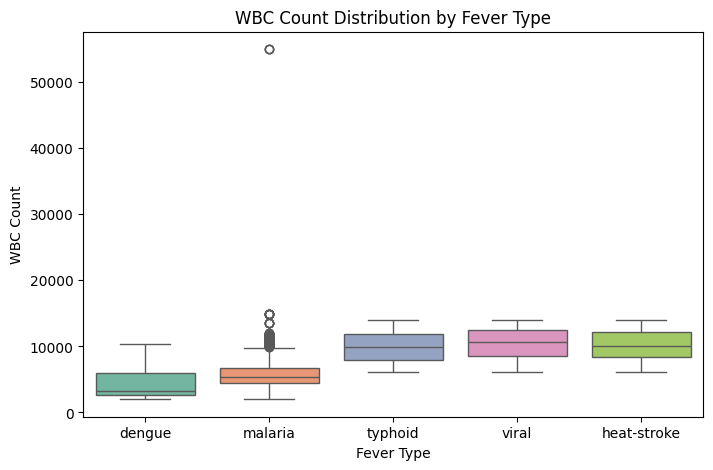

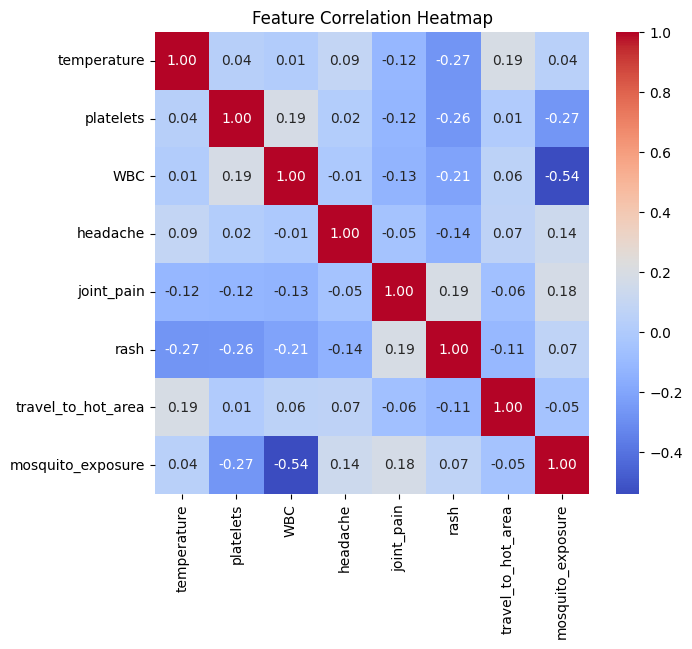

Accuracy: 0.9591567852437418
[[209   0  11   0   0]
 [  0  37   0   0   0]
 [  3   0 428   0   0]
 [  0   0   0  28   6]
 [  0   0   0  11  26]]
              precision    recall  f1-score   support

      dengue       0.99      0.95      0.97       220
 heat-stroke       1.00      1.00      1.00        37
     malaria       0.97      0.99      0.98       431
     typhoid       0.72      0.82      0.77        34
       viral       0.81      0.70      0.75        37

    accuracy                           0.96       759
   macro avg       0.90      0.89      0.89       759
weighted avg       0.96      0.96      0.96       759

Model pipeline saved as 'fever_model_pipeline.pkl'.


In [18]:
# ------------------------
# Import Packages
# ------------------------
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib
import os

# Ensure dataset folder exists
os.makedirs("datasets", exist_ok=True)

# ------------------------
# Load Dengue & Malaria datasets
# ------------------------
df_dengue = pd.read_csv("Dengue  dataset.csv")
df_malaria = pd.read_csv("Malaria  dataset.csv")

# ------------------------
# Map actual lab column names to standard names
# ------------------------
# Dengue
df_dengue = df_dengue.rename(columns={
    "Platelet Count": "platelets",
    "WBC Count": "WBC"
})

# Malaria
df_malaria = df_malaria.rename(columns={
    "Platelet Count": "platelets",
    "Total WBC count(/cumm)": "WBC"
})

# Strip extra spaces from column names
df_dengue.columns = df_dengue.columns.str.strip()
df_malaria.columns = df_malaria.columns.str.strip()

# Check column names
print("Dengue columns:", df_dengue.columns.tolist())
print("Malaria columns:", df_malaria.columns.tolist())

# ------------------------
# Select lab columns safely
# ------------------------
lab_columns = ["platelets", "WBC"]
df_dengue_labs = df_dengue[lab_columns]
df_malaria_labs = df_malaria[lab_columns]
print("Lab columns loaded successfully.")

# ------------------------
# Function to simulate realistic symptoms for ALL fever types
# ------------------------
def simulate_symptoms(fever_type, n, lab_data=None):
    if fever_type == "dengue":
        headache = np.random.choice([0,1], n, p=[0.1,0.9])
        joint_pain = np.random.choice([0,1], n, p=[0.3,0.7])
        rash = np.random.choice([0,1], n, p=[0.2,0.8])
        travel_to_hot_area = np.random.choice([0,1], n, p=[0.8,0.2])
        mosquito_exposure = np.ones(n, dtype=int)
        temperature = np.random.uniform(38,40, n)
    elif fever_type == "malaria":
        headache = np.ones(n, dtype=int)
        joint_pain = np.random.choice([0,1], n, p=[0.5,0.5])
        rash = np.zeros(n, dtype=int)
        travel_to_hot_area = np.random.choice([0,1], n, p=[0.7,0.3])
        mosquito_exposure = np.ones(n, dtype=int)
        temperature = np.random.uniform(38,41, n)
    elif fever_type == "typhoid":
        headache = np.random.choice([0,1], n, p=[0.3,0.7])
        joint_pain = np.random.choice([0,1], n, p=[0.5,0.5])
        rash = np.zeros(n, dtype=int)
        travel_to_hot_area = np.zeros(n, dtype=int)
        mosquito_exposure = np.zeros(n, dtype=int)
        temperature = np.random.uniform(38,40, n)
    elif fever_type == "viral":
        headache = np.ones(n, dtype=int)
        joint_pain = np.random.choice([0,1], n)
        rash = np.random.choice([0,1], n)
        travel_to_hot_area = np.zeros(n, dtype=int)
        mosquito_exposure = np.zeros(n, dtype=int)
        temperature = np.random.uniform(37.5,39, n)
    elif fever_type == "heat-stroke":
        headache = np.ones(n, dtype=int)
        joint_pain = np.zeros(n, dtype=int)
        rash = np.zeros(n, dtype=int)
        travel_to_hot_area = np.ones(n, dtype=int)
        mosquito_exposure = np.zeros(n, dtype=int)
        temperature = np.random.uniform(40,41, n)
    else:
        raise ValueError("Unknown fever type")

    # Use lab data if provided
    if lab_data is not None and len(lab_data) >= n:
        platelets = lab_data["platelets"].sample(n, replace=True).values
        WBC = lab_data["WBC"].sample(n, replace=True).values
    else:
        platelets = np.random.randint(120000,350000,n)
        WBC = np.random.randint(6000,14000,n)

    return pd.DataFrame({
        "temperature": temperature,
        "headache": headache,
        "joint_pain": joint_pain,
        "rash": rash,
        "travel_to_hot_area": travel_to_hot_area,
        "mosquito_exposure": mosquito_exposure,
        "platelets": platelets,
        "WBC": WBC,
        "fever_type": [fever_type]*n
    })

# ------------------------
# Generate simulated datasets
# ------------------------
dengue = simulate_symptoms("dengue", len(df_dengue), df_dengue_labs)
malaria = simulate_symptoms("malaria", len(df_malaria), df_malaria_labs)
typhoid = simulate_symptoms("typhoid", 200)
viral = simulate_symptoms("viral", 200)
heat_stroke = simulate_symptoms("heat-stroke", 200)

# ------------------------
# Combine all datasets
# ------------------------
combined = pd.concat([dengue, malaria, typhoid, viral, heat_stroke], ignore_index=True)
combined.to_csv("datasets/fever_data_real.csv", index=False)
print("Unified dataset created with realistic symptoms for ALL fever types!")


# ------------------------
# EDA Section – Colorful & Warning-Free
# ------------------------
import matplotlib.pyplot as plt
import seaborn as sns

df = combined  # use the combined dataset

# 1. Fever Type Distribution (Countplot)
plt.figure(figsize=(7,5))
sns.countplot(
    x="fever_type", data=df,
    palette="Set2", hue="fever_type", legend=False
)
plt.title("Number of Samples per Fever Type")
plt.xlabel("Fever Type")
plt.ylabel("Count")
plt.show()

# 2. Temperature Distribution by Fever Type (Boxplot)
plt.figure(figsize=(8,5))
sns.boxplot(
    x="fever_type", y="temperature", data=df,
    palette="Set3", hue="fever_type", legend=False
)
plt.title("Temperature Distribution by Fever Type")
plt.xlabel("Fever Type")
plt.ylabel("Temperature (°C)")
plt.show()

# 3. Platelets Distribution by Fever Type (Boxplot)
plt.figure(figsize=(8,5))
sns.boxplot(
    x="fever_type", y="platelets", data=df,
    palette="Set1", hue="fever_type", legend=False
)
plt.title("Platelet Count Distribution by Fever Type")
plt.xlabel("Fever Type")
plt.ylabel("Platelets")
plt.show()

# 4. WBC Distribution by Fever Type (Boxplot)
plt.figure(figsize=(8,5))
sns.boxplot(
    x="fever_type", y="WBC", data=df,
    palette="Set2", hue="fever_type", legend=False
)
plt.title("WBC Count Distribution by Fever Type")
plt.xlabel("Fever Type")
plt.ylabel("WBC Count")
plt.show()

# 5. Correlation Heatmap
plt.figure(figsize=(7,6))
sns.heatmap(
    df[["temperature","platelets","WBC","headache","joint_pain","rash","travel_to_hot_area","mosquito_exposure"]].corr(),
    annot=True, cmap="coolwarm", fmt=".2f"
)
plt.title("Feature Correlation Heatmap")
plt.show()


# ------------------------
# Preprocess and train RandomForest
# ------------------------
X = combined.drop("fever_type", axis=1)
y = combined["fever_type"]

numeric_features = ["temperature","platelets","WBC"]
categorical_features = ["headache","joint_pain","rash","travel_to_hot_area","mosquito_exposure"]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

clf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=200, random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
clf_pipeline.fit(X_train, y_train)

y_pred = clf_pipeline.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Save the model pipeline
joblib.dump(clf_pipeline, "fever_model_pipeline.pkl")
print("Model pipeline saved as 'fever_model_pipeline.pkl'.")


In [19]:
# Load the trained pipeline
clf_pipeline = joblib.load("fever_model_pipeline.pkl")

# Example new patient data
# You can provide lab values if available, or leave them as None / np.nan
new_patients = pd.DataFrame({
    "temperature": [39.2, 40.0, 38.5],
    "headache": [1, 1, 0],
    "joint_pain": [1, 0, 1],
    "rash": [0, 0, 1],
    "travel_to_hot_area": [0, 1, 0],
    "mosquito_exposure": [1, 0, 0],
    "platelets": [150000, 220000, np.nan],  # np.nan will be handled by pipeline
    "WBC": [8000, 10000, np.nan]            # np.nan will be handled by pipeline
})

# Predict fever type
predictions = clf_pipeline.predict(new_patients)
pred_probs = clf_pipeline.predict_proba(new_patients)

print("Predicted fever types:", predictions)
print("\nPrediction probabilities:\n", pd.DataFrame(pred_probs, columns=clf_pipeline.classes_))


Predicted fever types: ['malaria' 'heat-stroke' 'viral']

Prediction probabilities:
    dengue  heat-stroke  malaria  typhoid  viral
0   0.145         0.00    0.855    0.000   0.00
1   0.000         0.94    0.030    0.030   0.00
2   0.185         0.00    0.000    0.245   0.57
